In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import seaborn as sns
import numpy as np


In [2]:
dataset_path = './raw-img/'

classes = os.listdir(dataset_path)
print(classes)

['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [3]:
class_path = os.path.join(dataset_path, 'butterfly')
images = os.listdir(class_path)
print(images[:5])

['e030b20928e90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg', 'e030b20929e90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg', 'e030b2092be90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg', 'e030b2092ce90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg', 'e030b2092de90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg']


#### Testing to see if one image shows

Försöker läsa in: ./raw-img/butterfly\e030b20928e90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg


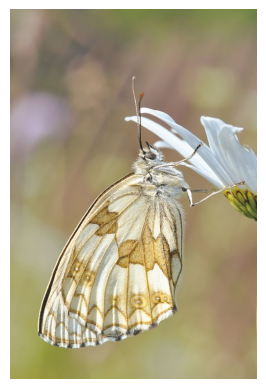

In [4]:
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(dataset_path, 'butterfly', images[0]) 
print(f"Försöker läsa in: {img_path}")

# Läs in bilden
img = cv2.imread(img_path)
if img is None:
    print(f"Kunde inte läsa in bilden: {img_path}")
else:
    # Konvertera från BGR till RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#### Show 5 of each class in subplots

Show pictures from class: butterfly


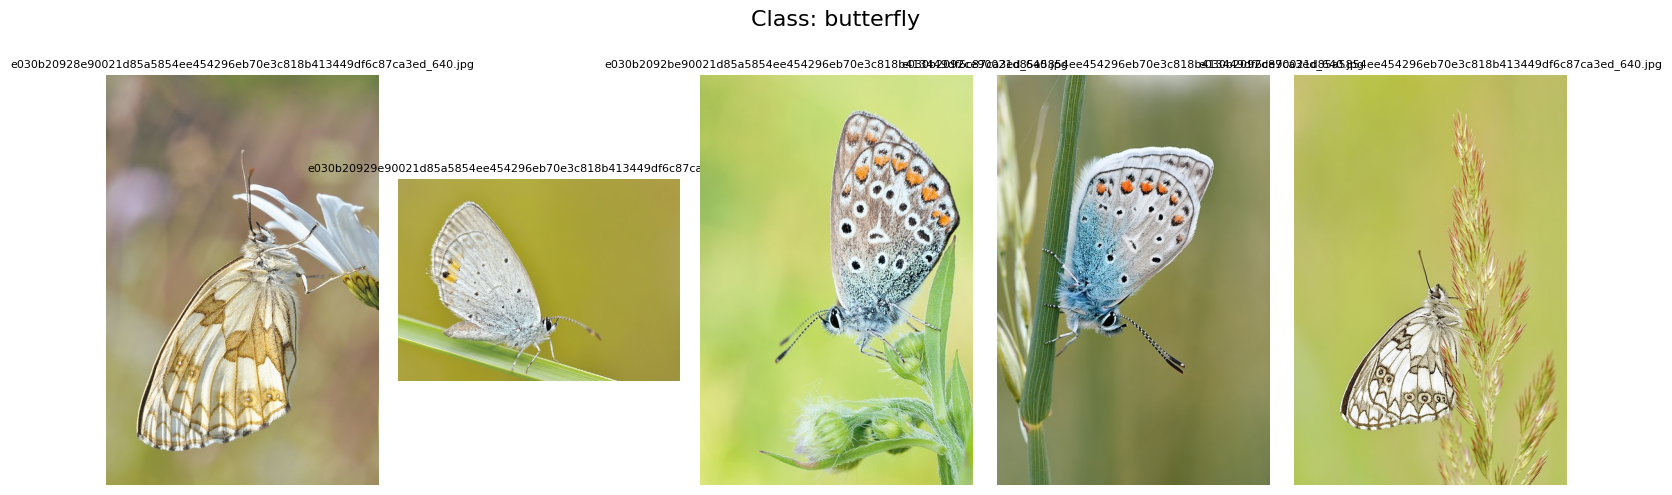

Show pictures from class: cat


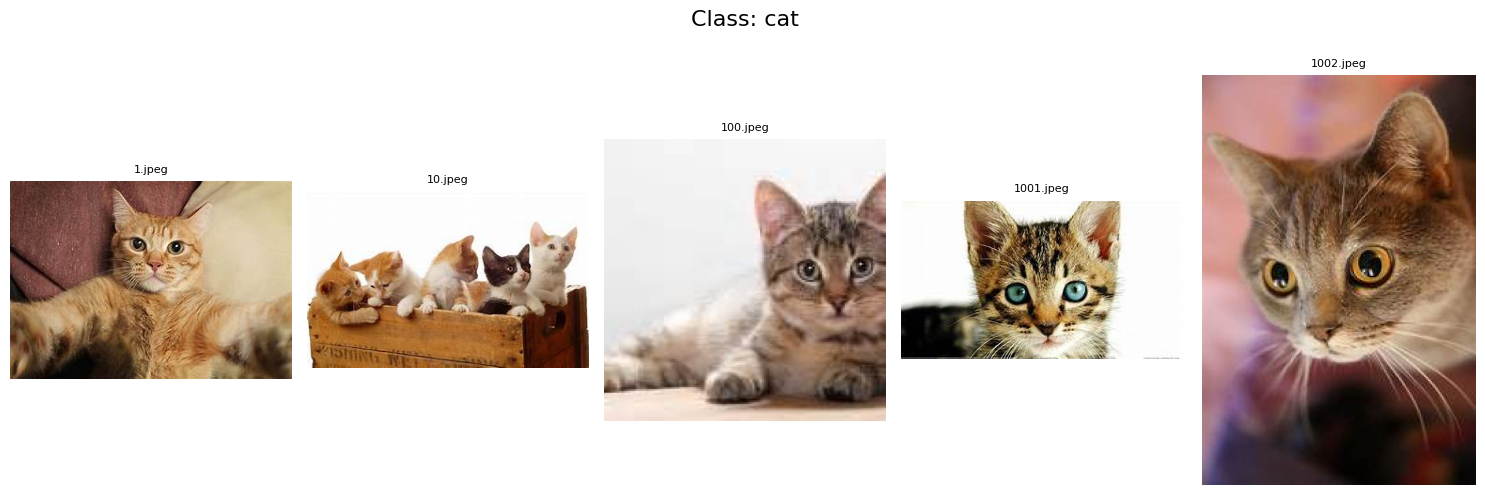

Show pictures from class: chicken


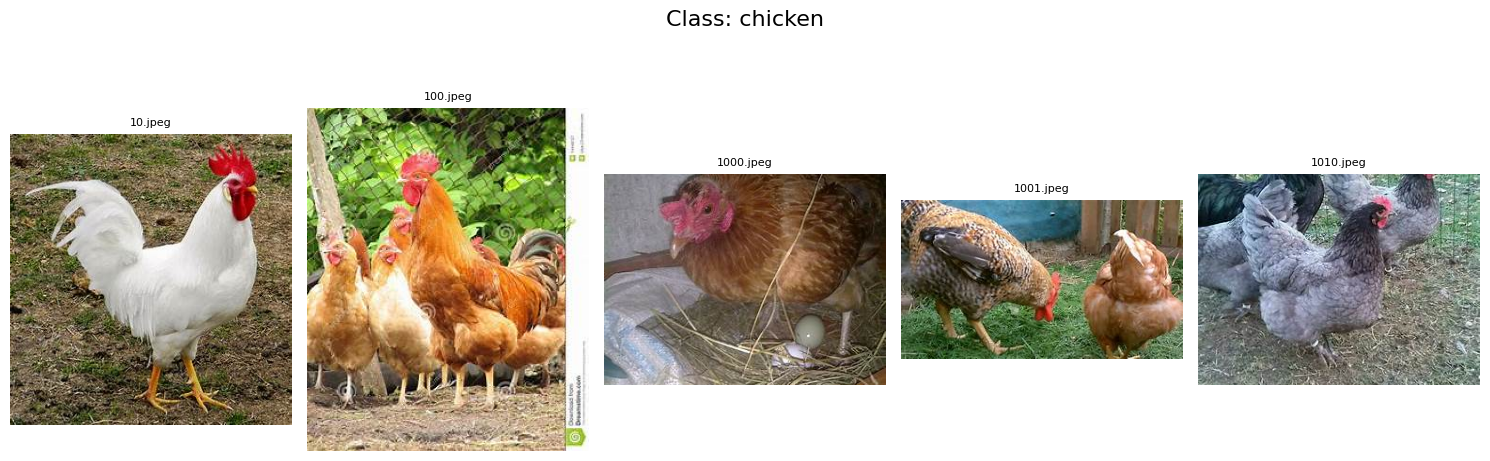

Show pictures from class: cow


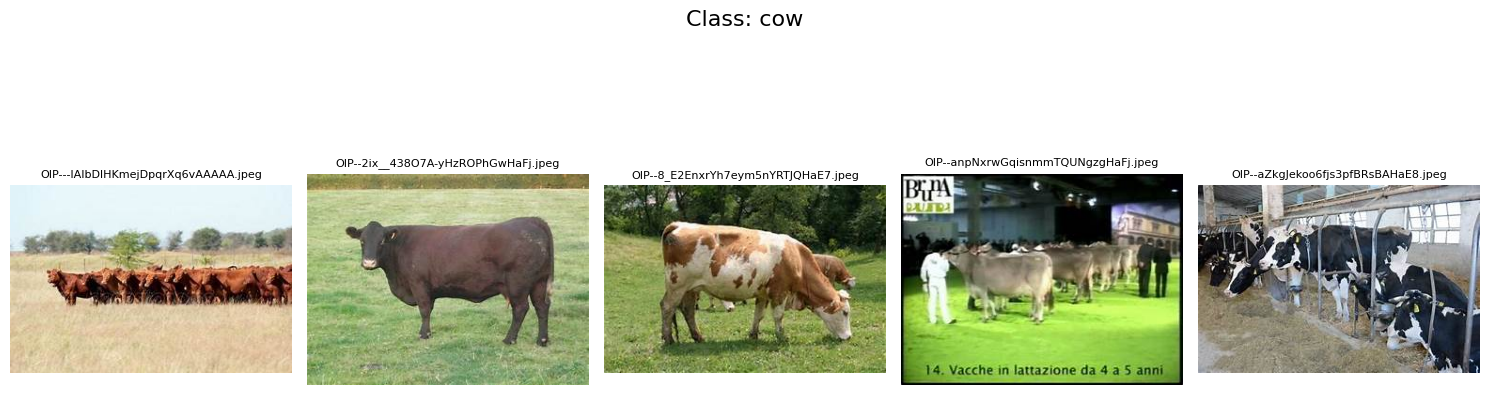

Show pictures from class: dog


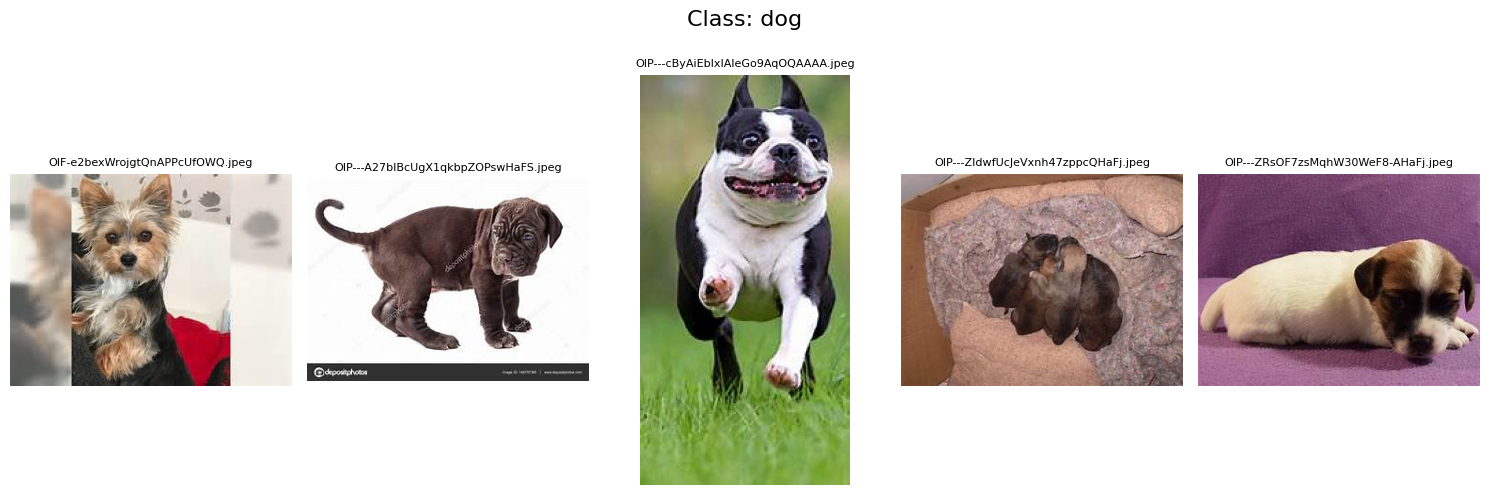

Show pictures from class: elephant


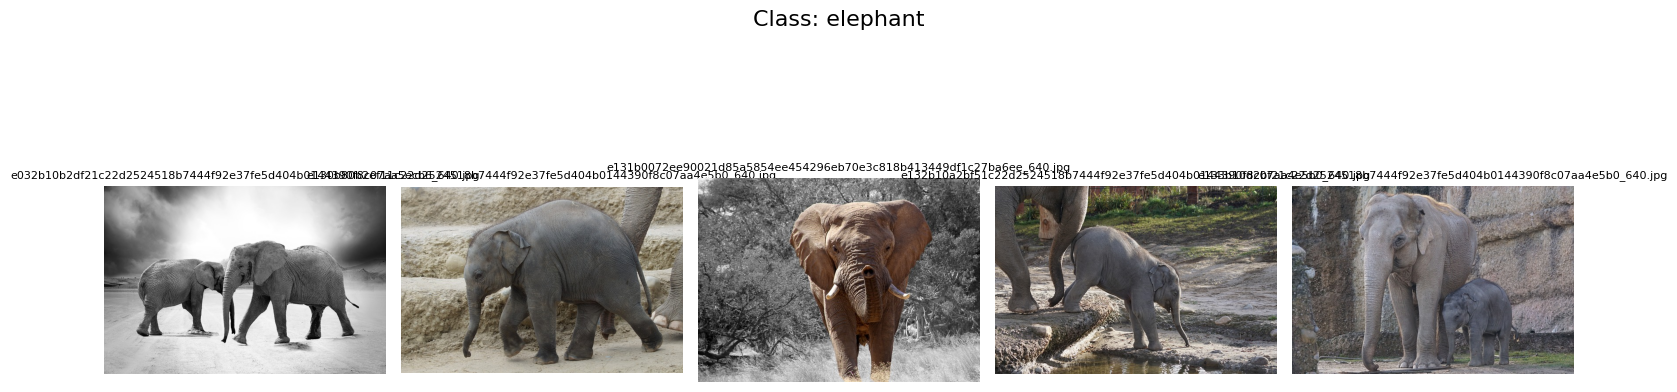

Show pictures from class: horse


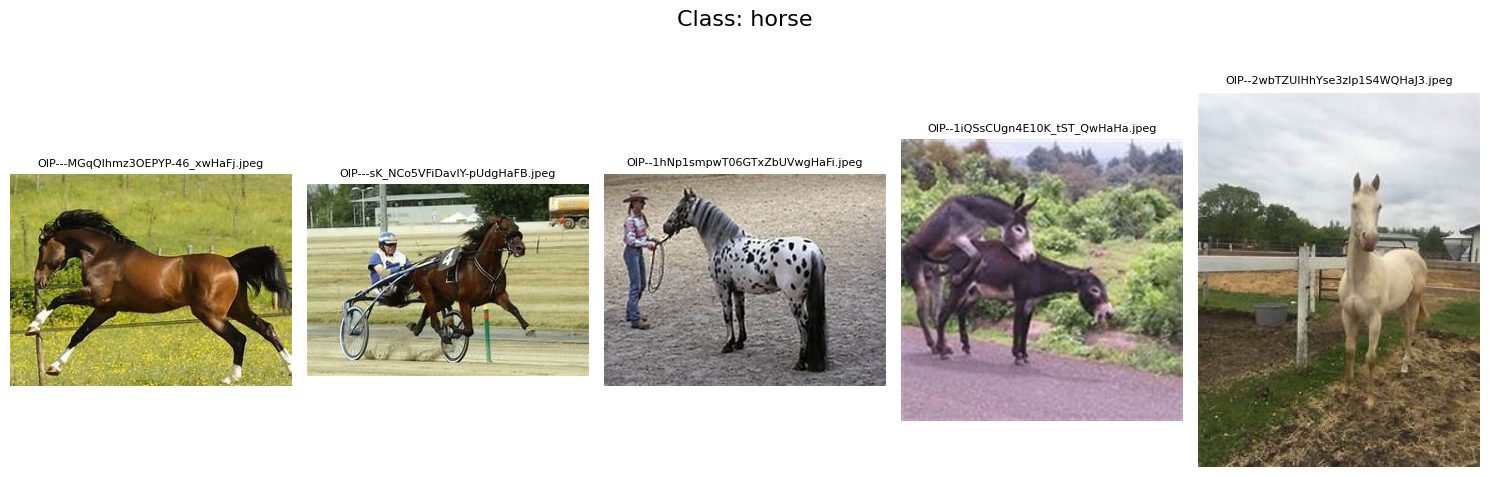

Show pictures from class: sheep


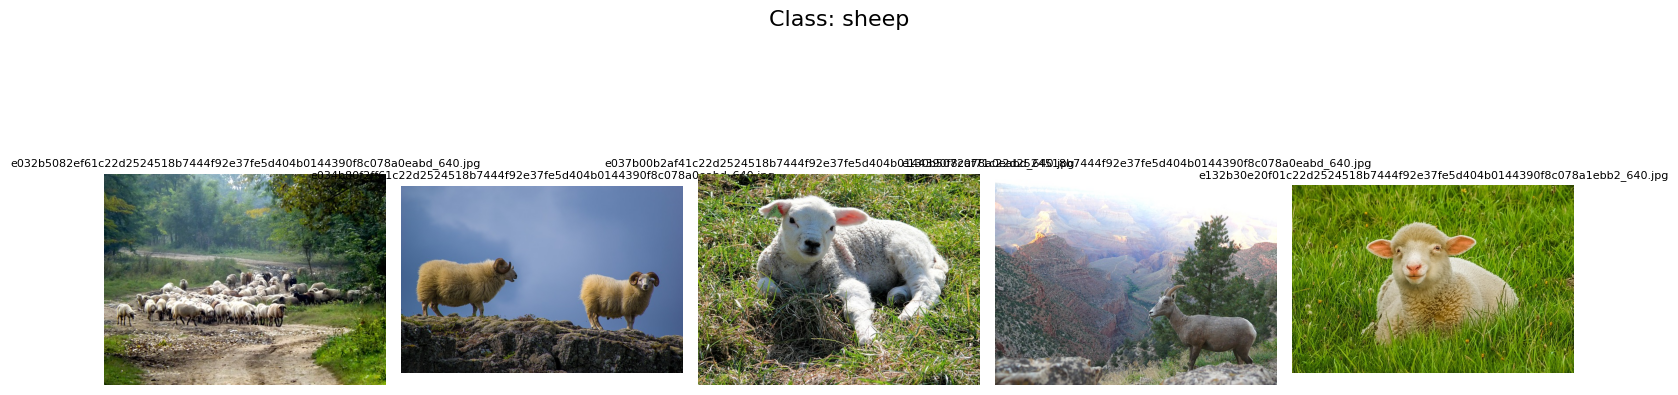

Show pictures from class: spider


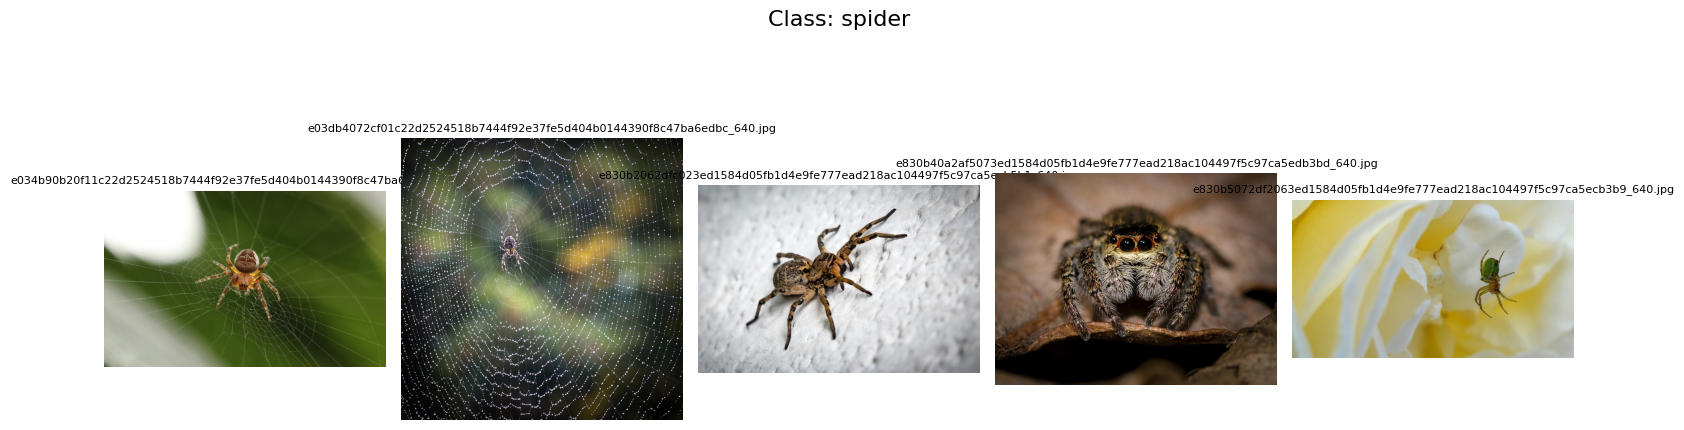

Show pictures from class: squirrel


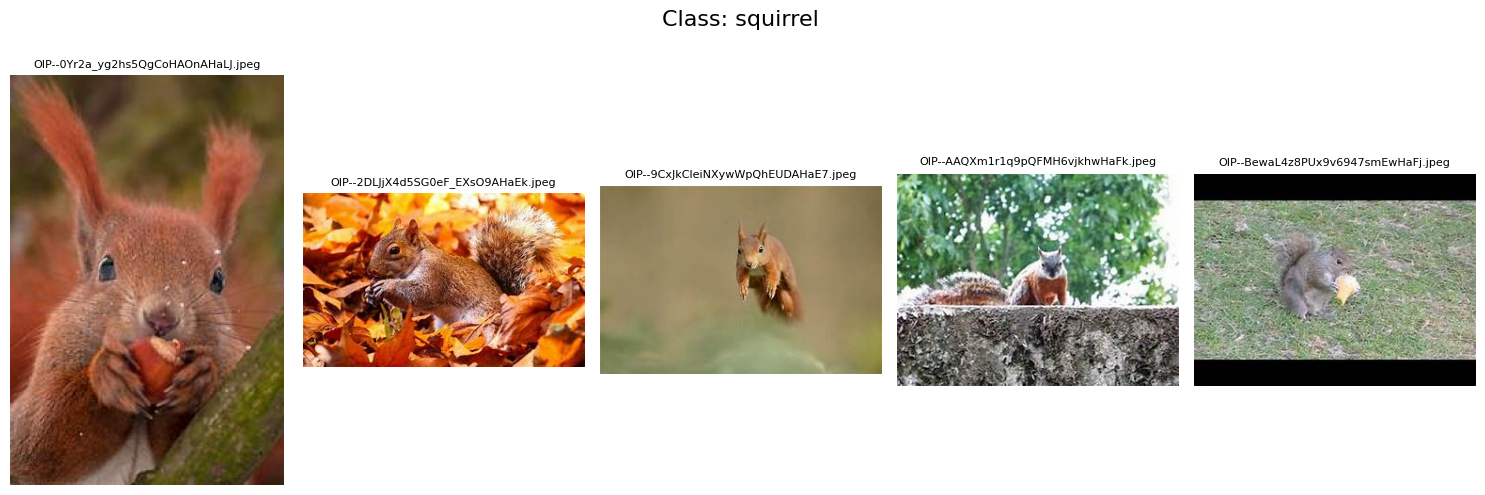

In [5]:

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)[:5]  
    print(f"Show pictures from class: {cls}")
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    fig.suptitle(f"Class: {cls}", fontsize=16)
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Couldnt read image: {img_path}")
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img)
        axes[i].set_title(img_name, fontsize=8)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85) 
    plt.show()

#### count amout of images in each class

In [6]:
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    num_images = len(os.listdir(cls_path))
    print(f"Class {cls} has {num_images} images")

Class butterfly has 2112 images
Class cat has 1668 images
Class chicken has 3098 images
Class cow has 1866 images
Class dog has 4863 images
Class elephant has 1446 images
Class horse has 2623 images
Class sheep has 1820 images
Class spider has 4821 images
Class squirrel has 1862 images


#### Visaulizing the dataset

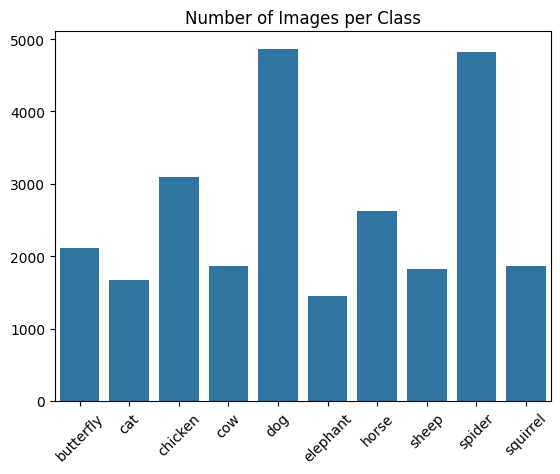

In [7]:
import seaborn as sns

class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.show()

#### resizing the images to make it more easy for modelltraining

In [8]:
img = cv2.resize(img, (128, 128))

img = img / 255.0

#### flattening the images and resizing them to so all images are the same

In [9]:
flattened_images = []
labels = []

# Iterera över alla klasser och bilder
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    
    for img_name in images:
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Kunde inte läsa in bilden: {img_path}")
            continue
        
        # Skala om bilden till en enhetlig storlek (t.ex. 128x128)
        img = cv2.resize(img, (128, 128))
        
        # Flattena bilden till en 1D-array
        flattened_images.append(img.flatten())
        
        # Lägg till klassens etikett
        labels.append(cls)

In [10]:
import numpy as np

flattened_images = np.array(flattened_images)
labels = np.array(labels)

In [11]:
print(labels[:10])  # Visa de första 10 etiketterna
print(type(labels))  # Kontrollera typen av labels

['butterfly' 'butterfly' 'butterfly' 'butterfly' 'butterfly' 'butterfly'
 'butterfly' 'butterfly' 'butterfly' 'butterfly']
<class 'numpy.ndarray'>


#### must convert to numerical values

In [12]:
from sklearn.preprocessing import LabelEncoder

# Konvertera strängetiketter till numeriska värden
label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(labels)

# Kontrollera de numeriska etiketterna
print(f"Original labels: {labels[:5]}")
print(f"Numeric labels: {numeric_labels[:5]}")

Original labels: ['butterfly' 'butterfly' 'butterfly' 'butterfly' 'butterfly']
Numeric labels: [0 0 0 0 0]


c:\Users\Nikla\OneDrive\AI developer\Tillämpad_AI\Programmering\gruppuppgifter\uppgift_4\animals-model\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Nikla\OneDrive\AI developer\Tillämpad_AI\Programmering\gruppuppgifter\uppgift_4\animals-model\venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Nikla\OneDrive\AI developer\Tillämpad_AI\Programmering\gruppuppgifter\uppgift_4\animals-model\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


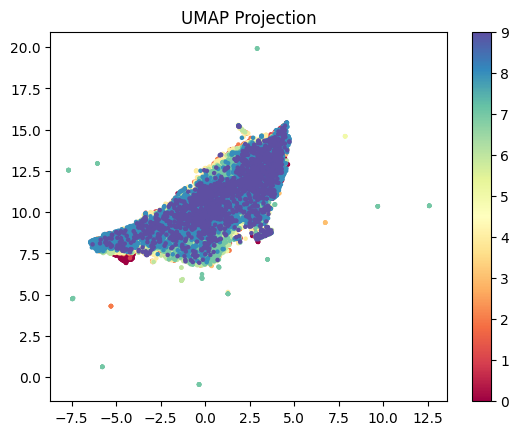

In [13]:
flattened_img = img.flatten()

from umap.umap_ import UMAP

reducer = UMAP(n_components=2, random_state=42)
embeddings = reducer.fit_transform(flattened_images)

plt.scatter(embeddings[:, 0], embeddings[:, 1], c=numeric_labels, cmap='Spectral', s=5)
plt.colorbar()
plt.title("UMAP Projection")
plt.show()  # flattened_images är en lista med alla bilder

#### lots of overlapping colors. Might be because the images are visually equal. Also see some outliers.

In [14]:
selected_points = (embeddings[:, 0] > -5) & (embeddings[:, 0] < 0) & (embeddings[:, 1] > 5) & (embeddings[:, 1] < 10)
selected_images = flattened_images[selected_points]
selected_labels = labels[selected_points]

print(f"Antal valda bilder: {len(selected_images)}")

Antal valda bilder: 7143


Recreating selected images to show them

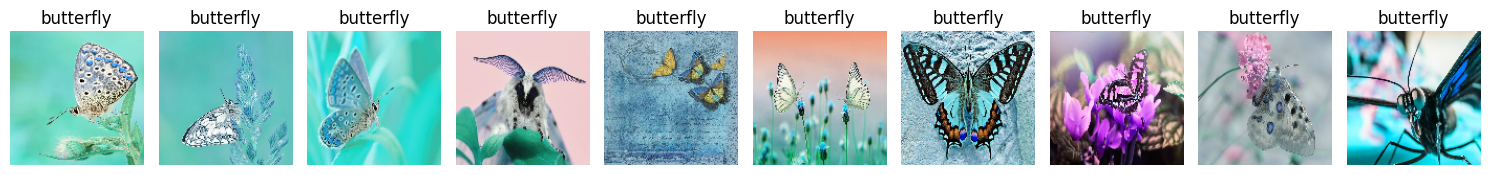

In [15]:
# Visa de valda bilderna i ett rutnät
fig, axes = plt.subplots(1, min(len(selected_images), 10), figsize=(15, 5))  # Visa upp till 10 bilder
for i, ax in enumerate(axes):
    if i >= len(selected_images):
        break
    # Återskapa bilden från den flattenade arrayen
    img = selected_images[i].reshape(128, 128, 3)  # Anpassa storleken om du använde en annan storlek
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Kombinera flera områden
selected_points = ((embeddings[:, 0] > -5) & (embeddings[:, 0] < 0) & (embeddings[:, 1] > 5) & (embeddings[:, 1] < 10)) | \
                  ((embeddings[:, 0] > 5) & (embeddings[:, 0] < 10) & (embeddings[:, 1] > -5) & (embeddings[:, 1] < 0))

selected_images = flattened_images[selected_points]
selected_labels = labels[selected_points]

print(f"Antal valda bilder: {len(selected_images)}")
print(f"Valda etiketter: {np.unique(selected_labels)}")


Antal valda bilder: 7143
Valda etiketter: ['butterfly' 'cat' 'chicken' 'cow' 'dog' 'elephant' 'horse' 'sheep'
 'spider' 'squirrel']


In [17]:
from collections import Counter

class_counts = Counter(labels)
print(class_counts)

Counter({np.str_('dog'): 4863, np.str_('spider'): 4821, np.str_('chicken'): 3098, np.str_('horse'): 2623, np.str_('butterfly'): 2112, np.str_('cow'): 1866, np.str_('squirrel'): 1862, np.str_('sheep'): 1820, np.str_('cat'): 1668, np.str_('elephant'): 1446})


##### use dataaugmentation to emprove the variation in the dataset and prepare for modell training